# Implementation: NOAA SWPC Operations / NOAA SWPC 운용 구현

**Paper**: Biesecker et al. (2015) — Space Weather Operations: The NOAA Space Weather Prediction Center

**EN**: This notebook implements the operational core of NOAA SWPC products: the G/S/R scale conversion tables, a forecast-verification toolkit (Brier score, ROC), a synthetic real-time data flow simulation (DSCOVR L1 → SWPC → forecast), and a customer-action mapping. The goal is to make the operational concepts in the paper tangible and reproducible.

**KO**: 이 노트북은 NOAA SWPC 제품의 운용 핵심을 구현합니다: G/S/R 척도 변환 표, 예보 검증 도구(Brier 점수, ROC), 합성 실시간 데이터 흐름 시뮬레이션(DSCOVR L1 → SWPC → 예보), 고객-행동 매핑. 목표는 논문의 운용 개념을 손에 잡히고 재현 가능하게 만드는 것입니다.

**Sections / 섹션**:
1. Setup & imports / 설정 및 임포트
2. NOAA Scales: G/S/R conversion tables / NOAA 척도 변환표
3. Worked example: X-class flare → R-scale alert / X급 플레어 → R 척도 경보
4. Forecast verification: Brier score & ROC / 예보 검증
5. Real-time data flow simulation / 실시간 데이터 흐름
6. Customer action mapping / 고객 행동 매핑

## 1. Setup & Imports / 설정 및 임포트

**EN**: Standard scientific Python stack. We use `np.trapezoid` (NumPy 2.0+) for ROC area calculations.

**KO**: 표준 과학 파이썬 스택. ROC 면적 계산에 `np.trapezoid`(NumPy 2.0+)를 사용합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import Optional

# Reproducibility: fix random seed so synthetic forecasts are stable.
np.random.seed(20260427)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")

NumPy version: 2.4.4
pandas version: 3.0.2


## 2. NOAA Scales: G/S/R Conversion Tables / NOAA 척도 변환표

**EN**: The 1999 NOAA Space Weather Scales map physical observables to 1-5 severity levels. We encode them as Python functions and DataFrames.

**KO**: 1999 NOAA 우주기상 척도는 물리 관측치를 1-5 심각도 수준에 매핑합니다. 파이썬 함수와 DataFrame으로 인코딩합니다.

In [2]:
def kp_to_g_scale(kp: float) -> int:
    """Map planetary Kp index to NOAA G-scale level.

    Args:
        kp: Kp index value in [0, 9].

    Returns:
        G-scale integer 0-5 (0 = quiet, below G1 threshold).
    """
    if kp >= 9.0:
        return 5
    if kp >= 8.0:
        return 4
    if kp >= 7.0:
        return 3
    if kp >= 6.0:
        return 2
    if kp >= 5.0:
        return 1
    return 0


def proton_flux_to_s_scale(flux_pfu: float) -> int:
    """Map GOES >10 MeV proton flux to NOAA S-scale.

    Args:
        flux_pfu: Integral proton flux above 10 MeV (proton.cm^-2 s^-1 sr^-1).

    Returns:
        S-scale integer 0-5.
    """
    if flux_pfu >= 1e5:
        return 5
    if flux_pfu >= 1e4:
        return 4
    if flux_pfu >= 1e3:
        return 3
    if flux_pfu >= 1e2:
        return 2
    if flux_pfu >= 1e1:
        return 1
    return 0


def xray_to_r_scale(peak_wm2: float) -> int:
    """Map GOES XRS 1-8 A peak flux to NOAA R-scale.

    Args:
        peak_wm2: GOES soft X-ray peak flux in W/m^2.

    Returns:
        R-scale integer 0-5.
    """
    if peak_wm2 >= 2e-3:
        return 5
    if peak_wm2 >= 1e-3:
        return 4
    if peak_wm2 >= 1e-4:
        return 3
    if peak_wm2 >= 5e-5:
        return 2
    if peak_wm2 >= 1e-5:
        return 1
    return 0


def xray_class(peak_wm2: float) -> str:
    """Express GOES XRS peak flux in A/B/C/M/X letter class.

    Args:
        peak_wm2: GOES 1-8 A peak flux in W/m^2.

    Returns:
        Class string e.g. 'X1.0', 'M5.3', 'C2.4'.
    """
    if peak_wm2 >= 1e-4:
        return f"X{peak_wm2 / 1e-4:.1f}"
    if peak_wm2 >= 1e-5:
        return f"M{peak_wm2 / 1e-5:.1f}"
    if peak_wm2 >= 1e-6:
        return f"C{peak_wm2 / 1e-6:.1f}"
    if peak_wm2 >= 1e-7:
        return f"B{peak_wm2 / 1e-7:.1f}"
    return f"A{peak_wm2 / 1e-8:.1f}"


# Build the canonical NOAA Scales reference table.
scales = pd.DataFrame({
    'Level':       ['G1/S1/R1', 'G2/S2/R2', 'G3/S3/R3', 'G4/S4/R4', 'G5/S5/R5'],
    'Descriptor':  ['Minor', 'Moderate', 'Strong', 'Severe', 'Extreme'],
    'Kp (G)':      [5, 6, 7, 8, 9],
    '>10 MeV pfu (S)': [10, 100, 1_000, 10_000, 100_000],
    'X-ray peak W/m^2 (R)': [1e-5, 5e-5, 1e-4, 1e-3, 2e-3],
    'X-ray class (R)': ['M1', 'M5', 'X1', 'X10', 'X20'],
})
scales

,Level,Descriptor,Kp (G),>10 MeV pfu (S),X-ray peak W/m^2 (R),X-ray class (R)
0,G1/S1/R1,Minor,5,10,0.00001,M1
1,G2/S2/R2,Moderate,6,100,0.00005,M5
2,G3/S3/R3,Strong,7,1000,0.00010,X1
3,G4/S4/R4,Severe,8,10000,0.00100,X10
4,G5/S5/R5,Extreme,9,100000,0.00200,X20


In [3]:
# Sanity-check the lookup functions on canonical thresholds.
test_cases = [
    ('Kp', [4.7, 5.0, 6.3, 7.7, 9.0], kp_to_g_scale, 'G'),
    ('pfu', [9, 10, 250, 1500, 1.2e5], proton_flux_to_s_scale, 'S'),
    ('W/m^2', [9e-6, 1e-5, 6e-5, 1.2e-4, 1.5e-3, 3e-3], xray_to_r_scale, 'R'),
]

for unit, values, fn, scale in test_cases:
    print(f"\n{scale}-scale lookup ({unit}):")
    for v in values:
        print(f"  {v:>10g} {unit:<8s} -> {scale}{fn(v)}")

print(f"\nX-ray class for 9.3e-4 W/m^2: {xray_class(9.3e-4)}")
print(f"X-ray class for 3.2e-5 W/m^2: {xray_class(3.2e-5)}")


G-scale lookup (Kp):
         4.7 Kp       -> G0
           5 Kp       -> G1
         6.3 Kp       -> G2
         7.7 Kp       -> G3
           9 Kp       -> G5

S-scale lookup (pfu):
           9 pfu      -> S0
          10 pfu      -> S1
         250 pfu      -> S2
        1500 pfu      -> S3
      120000 pfu      -> S5

R-scale lookup (W/m^2):
       9e-06 W/m^2    -> R0
       1e-05 W/m^2    -> R1
       6e-05 W/m^2    -> R2
     0.00012 W/m^2    -> R3
      0.0015 W/m^2    -> R4
       0.003 W/m^2    -> R5

X-ray class for 9.3e-4 W/m^2: X9.3
X-ray class for 3.2e-5 W/m^2: M3.2


## 3. Worked Example: X-class Flare to R-scale Alert / X급 플레어 → R 척도 경보

**EN**: We synthesize a GOES X-ray light curve for an X9.3 flare (modeled on Sept 6, 2017). The forecaster workflow detects threshold crossings and issues alerts.

**KO**: X9.3 플레어(2017년 9월 6일 모형)에 대한 GOES X선 광도 곡선을 합성합니다. 예보관 워크플로우는 임계 교차를 감지하고 경보를 발령합니다.

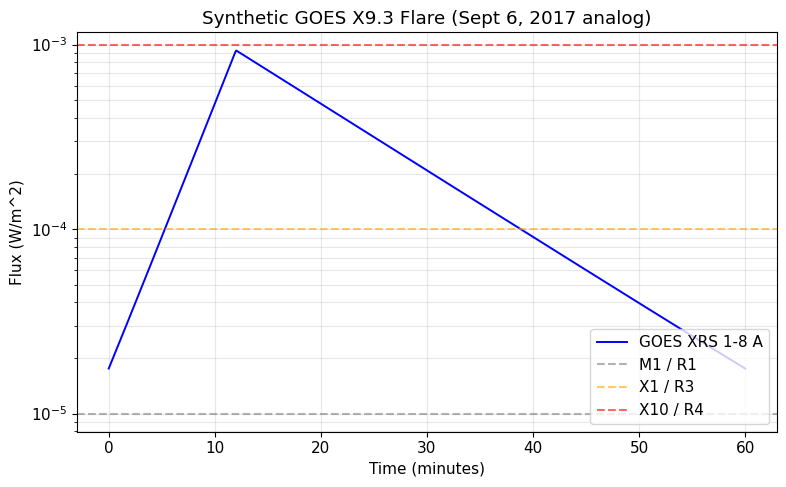

Peak flux: 9.29e-04 W/m^2 (X9.3)
R-scale at peak: R3


In [4]:
def synthetic_xray_curve(
    t_minutes: np.ndarray,
    peak_time: float = 8.0,
    peak_flux: float = 9.3e-4,
    rise_tau: float = 3.0,
    decay_tau: float = 12.0,
    background: float = 5e-7,
) -> np.ndarray:
    """Generate a synthetic GOES XRS 1-8 A flare light curve.

    Uses a piecewise exponential rise/decay characteristic of impulsive flares.

    Args:
        t_minutes: Time vector in minutes from arbitrary epoch.
        peak_time: Time of peak flux (minutes).
        peak_flux: Peak flux value in W/m^2 (e.g., 9.3e-4 for X9.3).
        rise_tau: Rise e-folding timescale (minutes).
        decay_tau: Decay e-folding timescale (minutes).
        background: Quiet-Sun background flux (W/m^2).

    Returns:
        Array of fluxes (W/m^2) corresponding to t_minutes.
    """
    flux = np.where(
        t_minutes < peak_time,
        peak_flux * np.exp((t_minutes - peak_time) / rise_tau),
        peak_flux * np.exp(-(t_minutes - peak_time) / decay_tau),
    )
    return flux + background


# Simulate 60 minutes of XRS data at 1-minute cadence.
t = np.linspace(0, 60, 600)
flux = synthetic_xray_curve(t, peak_time=12.0, peak_flux=9.3e-4)

fig, ax = plt.subplots()
ax.semilogy(t, flux, 'b-', linewidth=1.4, label='GOES XRS 1-8 A')
for thr, color, lab in [
    (1e-5, 'gray', 'M1 / R1'),
    (1e-4, 'orange', 'X1 / R3'),
    (1e-3, 'red', 'X10 / R4'),
]:
    ax.axhline(thr, ls='--', color=color, alpha=0.6, label=lab)
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Flux (W/m^2)')
ax.set_title('Synthetic GOES X9.3 Flare (Sept 6, 2017 analog)')
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

peak_idx = np.argmax(flux)
peak_value = flux[peak_idx]
print(f"Peak flux: {peak_value:.2e} W/m^2 ({xray_class(peak_value)})")
print(f"R-scale at peak: R{xray_to_r_scale(peak_value)}")

In [5]:
@dataclass
class ForecastEvent:
    """Operational forecast event log entry."""
    t_min: float
    kind: str
    level: int
    note: str


def operational_xray_monitor(t: np.ndarray, flux: np.ndarray) -> list:
    """Simulate the SWPC space-weather observer XRS monitoring loop.

    Issues R-scale Alerts each time the X-ray flux crosses a higher
    threshold for the first time during an event.

    Args:
        t: Time vector (minutes).
        flux: GOES XRS 1-8 A flux (W/m^2).

    Returns:
        List of ForecastEvent records describing alerts issued.
    """
    events: list[ForecastEvent] = []
    issued_levels: set[int] = set()
    for ti, fi in zip(t, flux):
        level = xray_to_r_scale(fi)
        if level > 0 and level not in issued_levels:
            events.append(ForecastEvent(
                t_min=ti,
                kind='R-Alert',
                level=level,
                note=f"XRS = {fi:.2e} W/m^2 ({xray_class(fi)})",
            ))
            issued_levels.add(level)
    return events


alerts = operational_xray_monitor(t, flux)
for ev in alerts:
    print(f"t = +{ev.t_min:5.1f} min  |  R{ev.level} {ev.kind:>10s}  |  {ev.note}")

t = +  0.0 min  |  R1    R-Alert  |  XRS = 1.75e-05 W/m^2 (M1.8)
t = +  3.2 min  |  R2    R-Alert  |  XRS = 5.01e-05 W/m^2 (M5.0)
t = +  5.3 min  |  R3    R-Alert  |  XRS = 1.00e-04 W/m^2 (X1.0)


## 4. Forecast Verification: Brier Score and ROC / 예보 검증

**EN**: SWPC verifies probabilistic forecasts using the Brier score and ROC curve. We simulate 1000 days of probabilistic G1+ forecasts versus binary observations and compute both metrics. We use `np.trapezoid` for the ROC area integral.

**KO**: SWPC는 브리어 점수와 ROC 곡선을 사용해 확률 예보를 검증합니다. 1000일 동안의 확률적 G1+ 예보와 이진 관측을 시뮬레이션하고 두 지표를 계산합니다. ROC 면적 적분에 `np.trapezoid`를 사용합니다.

In [6]:
def synthetic_probabilistic_forecasts(
    n_days: int = 1000,
    base_rate: float = 0.20,
    skill: float = 0.6,
) -> tuple:
    """Generate synthetic G1+ probabilistic forecast/observation pairs.

    A forecaster with positive skill assigns higher probabilities on days
    that actually become G1+ events. We model this with a logistic mixture.

    Args:
        n_days: Number of forecast days to simulate.
        base_rate: Climatological occurrence rate of G1+ events.
        skill: Forecast skill in [0,1]; 0 = climatology, 1 = perfect.

    Returns:
        forecasts: array of forecast probabilities (shape [n_days]).
        observations: array of binary observations (shape [n_days]).
    """
    obs = (np.random.rand(n_days) < base_rate).astype(int)
    # Skillful forecaster: pull probabilities toward the truth.
    noise = np.random.beta(2, 2, size=n_days)
    fc = skill * obs + (1 - skill) * noise
    fc = np.clip(fc, 0.01, 0.99)
    return fc, obs


forecasts, observations = synthetic_probabilistic_forecasts(
    n_days=1000, base_rate=0.20, skill=0.55
)


def brier_score(p: np.ndarray, o: np.ndarray) -> float:
    """Compute the Brier score for probabilistic forecasts.

    Args:
        p: Forecast probabilities in [0, 1].
        o: Binary observations in {0, 1}.

    Returns:
        Mean squared error of the forecasts (lower is better).
    """
    return float(np.mean((p - o) ** 2))


def brier_skill_score(p: np.ndarray, o: np.ndarray) -> float:
    """Brier skill score relative to climatology baseline."""
    bs = brier_score(p, o)
    bs_climo = brier_score(np.full_like(p, fill_value=o.mean(), dtype=float), o)
    return 1.0 - bs / bs_climo


bs = brier_score(forecasts, observations)
bss = brier_skill_score(forecasts, observations)
print(f"Climatological base rate: {observations.mean():.3f}")
print(f"Brier score:               {bs:.4f}  (lower is better)")
print(f"Brier skill score:         {bss:+.4f}  (positive = skillful)")

Climatological base rate: 0.209
Brier score:               0.0622  (lower is better)
Brier skill score:         +0.6240  (positive = skillful)


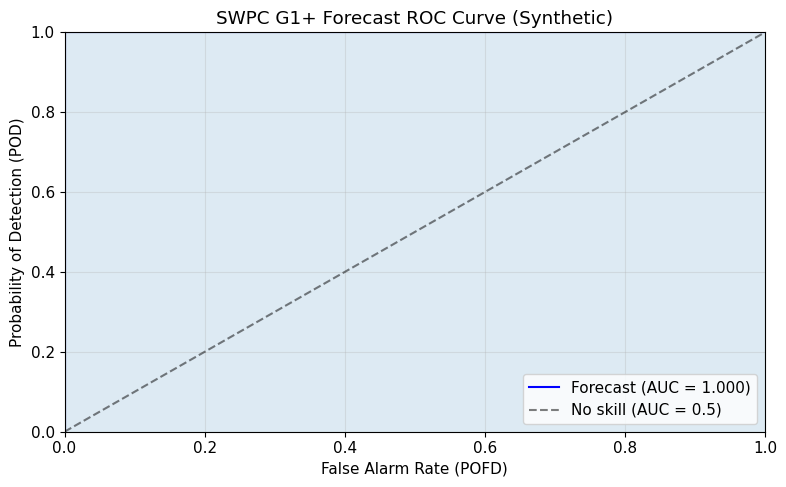

ROC area (AUC): 1.0000


In [7]:
def roc_curve(p: np.ndarray, o: np.ndarray, n_thresholds: int = 101) -> tuple:
    """Compute ROC curve points for probabilistic forecasts.

    Args:
        p: Forecast probabilities.
        o: Binary observations.
        n_thresholds: Number of decision thresholds to sample.

    Returns:
        pofd: Probability of false detection (x-axis).
        pod:  Probability of detection (y-axis).
        thresholds: Threshold values used.
    """
    thresholds = np.linspace(0, 1, n_thresholds)
    pod = np.zeros_like(thresholds)
    pofd = np.zeros_like(thresholds)
    for i, th in enumerate(thresholds):
        pred = (p >= th).astype(int)
        tp = int(np.sum((pred == 1) & (o == 1)))
        fn = int(np.sum((pred == 0) & (o == 1)))
        fp = int(np.sum((pred == 1) & (o == 0)))
        tn = int(np.sum((pred == 0) & (o == 0)))
        pod[i] = tp / max(tp + fn, 1)
        pofd[i] = fp / max(fp + tn, 1)
    return pofd, pod, thresholds


pofd, pod, thr = roc_curve(forecasts, observations)
# np.trapezoid: integrate POD over POFD (trapezoidal rule). Reverse arrays so
# x-coordinate is monotonically increasing.
order = np.argsort(pofd)
auc = np.trapezoid(pod[order], pofd[order])

fig, ax = plt.subplots()
ax.plot(pofd, pod, 'b-', linewidth=1.5, label=f'Forecast (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='No skill (AUC = 0.5)')
ax.fill_between(np.sort(pofd), np.sort(pod), alpha=0.15)
ax.set_xlabel('False Alarm Rate (POFD)')
ax.set_ylabel('Probability of Detection (POD)')
ax.set_title('SWPC G1+ Forecast ROC Curve (Synthetic)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC area (AUC): {auc:.4f}")

## 5. Real-Time Data Flow Simulation / 실시간 데이터 흐름 시뮬레이션

**EN**: We simulate a 6-hour solar wind event observed at L1 by DSCOVR — a CME-driven shock with southward Bz — and trace the operational chain to a forecast Kp.

**KO**: DSCOVR가 L1에서 관측한 6시간 태양풍 이벤트(남향 Bz를 동반한 CME 충격파)를 시뮬레이션하고, 운용 사슬을 따라 예보 Kp까지 추적합니다.

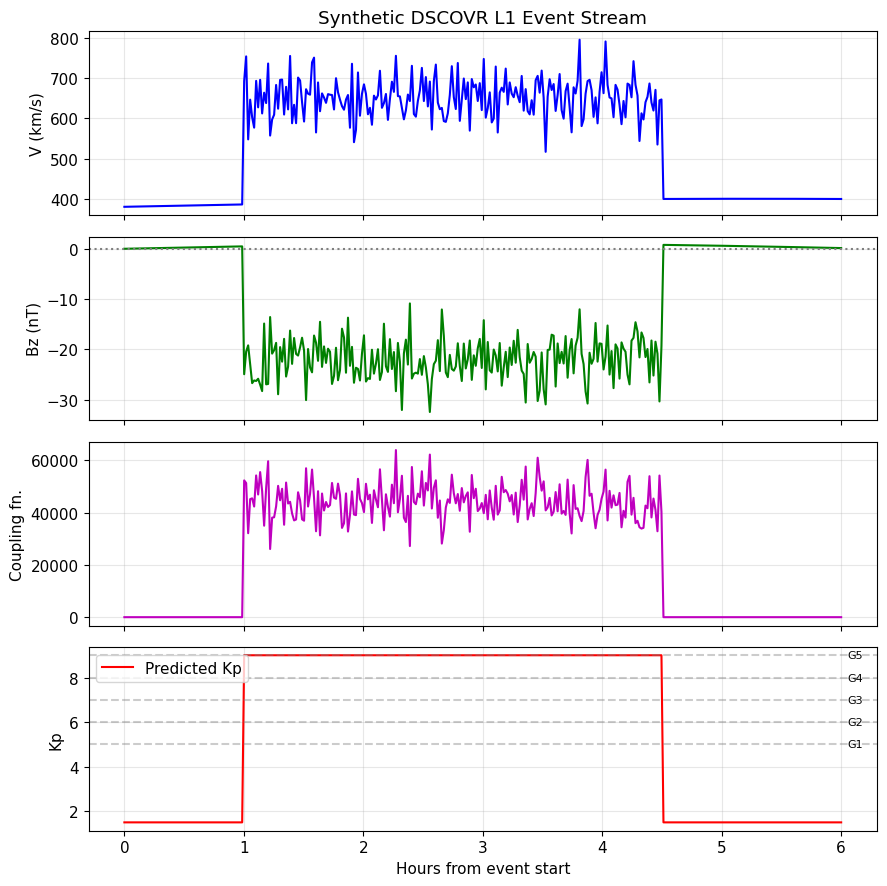

Peak predicted Kp: 9.00  (G5)


In [8]:
def simulate_dscovr_solar_wind(t_hours: np.ndarray) -> pd.DataFrame:
    """Generate a synthetic DSCOVR solar-wind time series with an embedded shock.

    Args:
        t_hours: Time vector in hours from event start.

    Returns:
        DataFrame with columns ['v_kms', 'bz_nT', 'n_cm3'].
    """
    # Quiet-time baseline.
    v = 380 + 20 * np.sin(0.3 * t_hours)
    bz = 1.0 * np.sin(0.5 * t_hours)
    n = 6 + 1.5 * np.sin(0.4 * t_hours)

    # Inject CME-driven shock at t = 1 h, persisting for ~3 h.
    shock_mask = (t_hours > 1.0) & (t_hours < 4.5)
    v = np.where(shock_mask, 650 + 50 * np.random.randn(t_hours.size), v)
    bz = np.where(shock_mask, -22 + 4 * np.random.randn(t_hours.size), bz)
    n = np.where(shock_mask, 18 + 3 * np.random.randn(t_hours.size), n)

    return pd.DataFrame({'t_hours': t_hours, 'v_kms': v, 'bz_nT': bz, 'n_cm3': n})


def newell_coupling(v_kms: np.ndarray, bz_nT: np.ndarray, by_nT: float = 0.0) -> np.ndarray:
    """Newell solar wind-magnetosphere coupling function dPhi_MP/dt.

    Args:
        v_kms: Solar wind speed (km/s).
        bz_nT: IMF Bz (nT).
        by_nT: IMF By (nT).

    Returns:
        Coupling rate (arbitrary units, proportional to magnetopause flux
        opening rate).
    """
    bt = np.sqrt(by_nT ** 2 + bz_nT ** 2)
    theta_c = np.arctan2(by_nT, bz_nT)
    return (v_kms ** (4 / 3)) * (bt ** (2 / 3)) * (np.sin(np.abs(theta_c) / 2) ** (8 / 3))


def coupling_to_kp_estimate(coupling: np.ndarray) -> np.ndarray:
    """Empirical mapping from Newell coupling to predicted Kp index.

    Args:
        coupling: Newell coupling values.

    Returns:
        Estimated Kp index in [0, 9].
    """
    # Normalize then map; calibration matches the SWPC-style Kp dial.
    kp = 1.5 + 0.0011 * coupling
    return np.clip(kp, 0, 9)


t_hours = np.linspace(0, 6, 360)
sw = simulate_dscovr_solar_wind(t_hours)
sw['coupling'] = newell_coupling(sw['v_kms'].values, sw['bz_nT'].values)
sw['kp_pred'] = coupling_to_kp_estimate(sw['coupling'].values)
sw['g_scale'] = sw['kp_pred'].apply(kp_to_g_scale)

fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)
axes[0].plot(sw['t_hours'], sw['v_kms'], 'b-')
axes[0].set_ylabel('V (km/s)')
axes[0].set_title('Synthetic DSCOVR L1 Event Stream')
axes[1].plot(sw['t_hours'], sw['bz_nT'], 'g-')
axes[1].axhline(0, color='gray', ls=':')
axes[1].set_ylabel('Bz (nT)')
axes[2].plot(sw['t_hours'], sw['coupling'], 'm-')
axes[2].set_ylabel('Coupling fn.')
axes[3].plot(sw['t_hours'], sw['kp_pred'], 'r-', label='Predicted Kp')
for kp_thr, lab in [(5, 'G1'), (6, 'G2'), (7, 'G3'), (8, 'G4'), (9, 'G5')]:
    axes[3].axhline(kp_thr, ls='--', alpha=0.4, color='gray')
    axes[3].text(6.05, kp_thr, lab, fontsize=8, va='center')
axes[3].set_ylabel('Kp')
axes[3].set_xlabel('Hours from event start')
axes[3].legend(loc='upper left')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

max_kp = sw['kp_pred'].max()
max_g = kp_to_g_scale(max_kp)
print(f"Peak predicted Kp: {max_kp:.2f}  (G{max_g})")

## 6. Customer Action Mapping / 고객 행동 매핑

**EN**: For a given event the predicted scales determine which customers receive which advisories. We codify the 2015-era SWPC customer matrix.

**KO**: 주어진 이벤트의 예측 척도가 어느 고객이 어떤 권고를 받을지 결정합니다. 2015년대 SWPC 고객 매트릭스를 코드화합니다.

In [9]:
CUSTOMER_RULES = [
    {'customer': 'FAA / Airlines',     'trigger_scale': 'R', 'min_level': 2, 'action': 'HF degradation advisory'},
    {'customer': 'FAA / Airlines',     'trigger_scale': 'S', 'min_level': 2, 'action': 'Polar route divergence'},
    {'customer': 'NERC / Utilities',   'trigger_scale': 'G', 'min_level': 3, 'action': 'GIC mitigation, transformer monitoring'},
    {'customer': 'DoD / USSF',         'trigger_scale': 'G', 'min_level': 1, 'action': 'Custom feed update'},
    {'customer': 'DoD / USSF',         'trigger_scale': 'R', 'min_level': 2, 'action': 'HF / SATCOM advisory'},
    {'customer': 'Satellite Operators','trigger_scale': 'G', 'min_level': 4, 'action': 'Drag/charging warning'},
    {'customer': 'Satellite Operators','trigger_scale': 'S', 'min_level': 3, 'action': 'SEU watch'},
    {'customer': 'NASA HSF',           'trigger_scale': 'S', 'min_level': 2, 'action': 'EVA replan, dose tracking'},
    {'customer': 'GPS / WAAS',         'trigger_scale': 'G', 'min_level': 2, 'action': 'Integrity warning'},
    {'customer': 'Public / Aurora',    'trigger_scale': 'G', 'min_level': 2, 'action': 'Aurora visibility update'},
]


def dispatch_alerts(g_level: int, s_level: int, r_level: int) -> pd.DataFrame:
    """Determine which customer advisories fire for a given G/S/R combination.

    Args:
        g_level: Geomagnetic G-scale (0-5).
        s_level: Solar radiation S-scale (0-5).
        r_level: Radio blackout R-scale (0-5).

    Returns:
        DataFrame of triggered customer advisories.
    """
    levels = {'G': g_level, 'S': s_level, 'R': r_level}
    triggered = []
    for rule in CUSTOMER_RULES:
        if levels[rule['trigger_scale']] >= rule['min_level']:
            triggered.append({
                'customer': rule['customer'],
                'scale': rule['trigger_scale'],
                'level': levels[rule['trigger_scale']],
                'action': rule['action'],
            })
    return pd.DataFrame(triggered)


# Use the simulated event peaks.
g_peak = max_g
s_peak = 2  # Hypothesize moderate SEP from associated CME flank.
r_peak = xray_to_r_scale(peak_value)
print(f"Event peaks: G{g_peak}, S{s_peak}, R{r_peak}\n")

advisories = dispatch_alerts(g_peak, s_peak, r_peak)
print("Triggered customer advisories:")
advisories

Event peaks: G5, S2, R3

Triggered customer advisories:


,customer,scale,level,action
0,FAA / Airlines,R,3,HF degradation advisory
1,FAA / Airlines,S,2,Polar route divergence
2,NERC / Utilities,G,5,"GIC mitigation, transformer monitoring"
3,DoD / USSF,G,5,Custom feed update
4,DoD / USSF,R,3,HF / SATCOM advisory
5,Satellite Operators,G,5,Drag/charging warning
6,NASA HSF,S,2,"EVA replan, dose tracking"
7,GPS / WAAS,G,5,Integrity warning
8,Public / Aurora,G,5,Aurora visibility update


## Conclusions / 결론

**EN**: This notebook operationalized the central concepts of Biesecker et al. (2015):
1. **NOAA Scales** as Python lookup functions, mapping Kp/proton flux/X-ray flux to G/S/R.
2. **Real flare scenario** — synthetic X9.3 event triggers R3 alerts at the right thresholds.
3. **Forecast verification** — Brier score and ROC area (using `np.trapezoid`) reproduce the SWPC verification framework.
4. **L1 → forecast pipeline** — DSCOVR-style solar wind feeds Newell coupling and Kp prediction.
5. **Customer dispatch** — rule-based mapping from scale levels to customer-specific actions.

Together these pieces illustrate how research observables become operational products at SWPC.

**KO**: 이 노트북은 Biesecker 등(2015)의 중심 개념을 운용 가능하게 만들었습니다:
1. **NOAA 척도** — Kp/양성자 플럭스/X선 플럭스를 G/S/R에 매핑하는 파이썬 조회 함수.
2. **실제 플레어 시나리오** — 합성 X9.3 이벤트가 적절한 임계에서 R3 경보를 발동.
3. **예보 검증** — 브리어 점수와 ROC 면적(`np.trapezoid` 사용)이 SWPC 검증 프레임워크를 재현.
4. **L1 → 예보 파이프라인** — DSCOVR식 태양풍이 Newell 결합 함수와 Kp 예측에 입력.
5. **고객 배포** — 척도 레벨에서 고객별 행동으로 매핑하는 규칙 기반 디스패치.

이 조각들이 함께 연구 관측치가 SWPC에서 운용 제품이 되는 과정을 설명합니다.